# Original data and excercise found at https://earthdatascience.org/courses/use-data-open-source-python/use-time-series-data-in-python/introduction-to-time-series-in-pandas-python/

In [117]:
#Install Libraries
!pip install matplotlib seaborn pandas earthpy numpy

In [118]:
#Import Packages
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from matplotlib.dates import DateFormatter
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import earthpy as et

# Handle date time conversions between pandas and matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Dealing with error thrown by one of the plots
matplotlib_axes_logger.setLevel('ERROR')
import warnings
warnings.filterwarnings('ignore')


# Adjust font size and style of all plots in notebook with seaborn
sns.set(font_scale=1.5, style="whitegrid")

In [119]:
et.data.get_data("colorado-flood")
data = pd.read_csv("/Users/noracook/sustainability_projects/colorado_flood_timeseries/colorado-flood/precipitation/805325-precip-daily-2003-2013.csv")
data.head()

,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,DATE,HPCP,Measurement Flag,Quality Flag
0,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030101 01:00,0.0,g,
1,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030201 01:00,0.0,g,
2,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030202 19:00,0.2,,
3,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030202 22:00,0.1,,
4,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,20030203 02:00,0.1,,


<Axes: title={'center': 'Daily Percipitation'}, xlabel='DATE'>

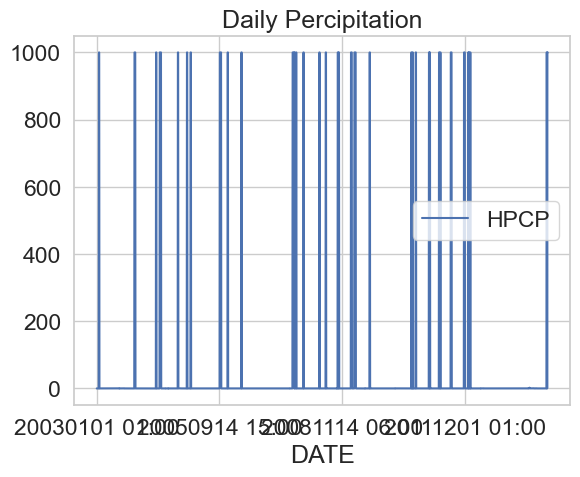

In [120]:
data.plot(x="DATE", y="HPCP", title="Daily Percipitation")

In [121]:
data["HPCP"].describe()

count    1840.000000
mean       51.192587
std       220.208147
min         0.000000
25%         0.100000
50%         0.100000
75%         0.100000
max       999.990000
Name: HPCP, dtype: float64

In [122]:
data.dtypes

STATION                 str
STATION_NAME            str
ELEVATION           float64
LATITUDE            float64
LONGITUDE           float64
DATE                    str
HPCP                float64
Measurement Flag        str
Quality Flag            str
dtype: object

In [123]:
# Import data using datetime and no data value

data=pd.read_csv("/Users/noracook/sustainability_projects/colorado_flood_timeseries/colorado-flood/precipitation/805325-precip-daily-2003-2013.csv",
                 parse_dates=["DATE"],
                 index_col=["DATE"],
                 na_values=["999.99"])

In [124]:
data.head()

,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,HPCP,Measurement Flag,Quality Flag
DATE,,,,,,,,
2003-01-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.0,g,
2003-02-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.0,g,
2003-02-02 19:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.2,,
2003-02-02 22:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,
2003-02-03 02:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,


In [125]:
data.describe()

,ELEVATION,LATITUDE,LONGITUDE,HPCP
count,1840.0,1840.000000,1840.000000,1746.000000
mean,1650.5,40.033851,-105.281106,0.111856
std,0.0,0.000045,0.000005,0.093222
min,1650.5,40.033800,-105.281110,0.000000
25%,1650.5,40.033800,-105.281110,0.100000
50%,1650.5,40.033890,-105.281110,0.100000
75%,1650.5,40.033890,-105.281100,0.100000
max,1650.5,40.033890,-105.281100,2.200000


In [126]:
data.index

DatetimeIndex(['2003-01-01 01:00:00', '2003-02-01 01:00:00',
               '2003-02-02 19:00:00', '2003-02-02 22:00:00',
               '2003-02-03 02:00:00', '2003-02-05 02:00:00',
               '2003-02-05 08:00:00', '2003-02-06 00:00:00',
               '2003-02-07 12:00:00', '2003-02-10 13:00:00',
               ...
               '2013-12-01 01:00:00', '2013-12-03 20:00:00',
               '2013-12-04 03:00:00', '2013-12-04 06:00:00',
               '2013-12-04 09:00:00', '2013-12-22 01:00:00',
               '2013-12-23 00:00:00', '2013-12-23 02:00:00',
               '2013-12-29 01:00:00', '2013-12-31 00:00:00'],
              dtype='datetime64[us]', name='DATE', length=1840, freq=None)

In [127]:
#data.reset_index

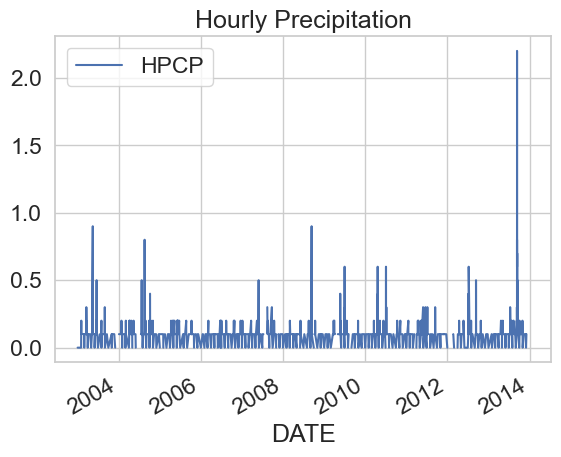

In [128]:
data.plot(y="HPCP",title="Hourly Precipitation")
plt.show()

In [129]:
# Subset data from 2005
data_2005=data.loc['2005']
data_2005.head()

,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,HPCP,Measurement Flag,Quality Flag
DATE,,,,,,,,
2005-01-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.0,g,
2005-01-02 06:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,NaN,{,
2005-01-02 08:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,NaN,},
2005-01-05 08:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,
2005-01-12 04:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.03389,-105.28111,0.1,,


In [130]:
# Remove missing values
precip_2005=data_2005.dropna()

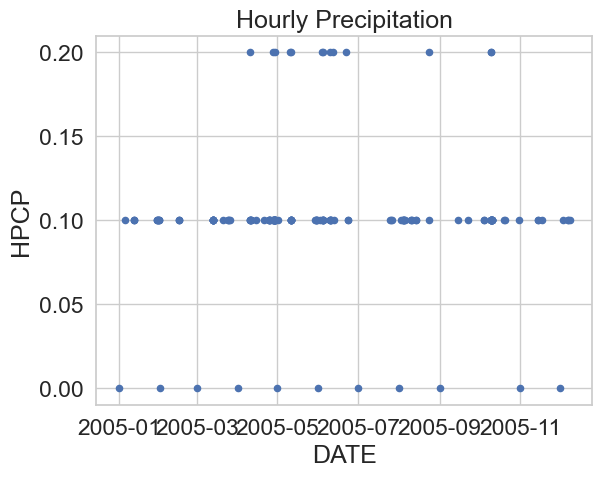

In [131]:
# Plot the data using pandas 

precip_2005.reset_index().plot(x="DATE",
                            y="HPCP",
                            title="Hourly Precipitation",
                            kind="scatter")
plt.show()

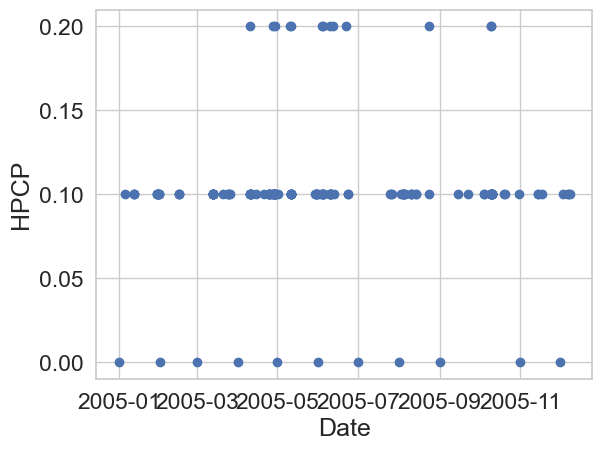

In [132]:
# Plot the data using native matplotlib
f, ax = plt.subplots()
ax.scatter(x=precip_2005.index, y=precip_2005["HPCP"])
plt.xlabel("Date")
plt.ylabel("HPCP")
plt.show()

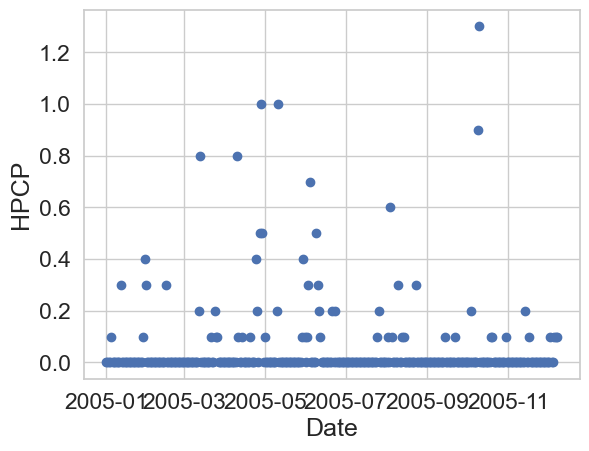

In [133]:
# Resample data so that it is the sum of each day

precip_2005_daily = precip_2005.resample("D").sum()

#plot the precipitation for 2005
f, ax = plt.subplots()
ax.scatter(x=precip_2005_daily.index, y=precip_2005_daily["HPCP"])
plt.xlabel("Date")
plt.ylabel("HPCP")
plt.show()

In [134]:
#Subset data for 2012 and 2013 and dropnas
precip_2012 = data.loc["2012"]
precip_2013 = data.loc["2013"]

precip_2012.dropna()
precip_2013.dropna()

,STATION,STATION_NAME,ELEVATION,LATITUDE,LONGITUDE,HPCP,Measurement Flag,Quality Flag
DATE,,,,,,,,
2013-01-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.0338,-105.2811,0.0,g,
2013-01-28 16:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.0338,-105.2811,0.1,,
2013-01-29 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.0338,-105.2811,0.1,,
2013-02-01 01:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.0338,-105.2811,0.0,g,
2013-02-14 16:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.0338,-105.2811,0.1,,
...,...,...,...,...,...,...,...,...
2013-12-03 20:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.0338,-105.2811,0.1,,
2013-12-04 03:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.0338,-105.2811,0.1,,
2013-12-04 06:00:00,COOP:050843,BOULDER 2 CO US,1650.5,40.0338,-105.2811,0.1,,


In [135]:
# Resample data so that it is the sum of each day

precip_2012_daily = precip_2012.resample("D").sum()
precip_2013_daily = precip_2013.resample("D").sum()

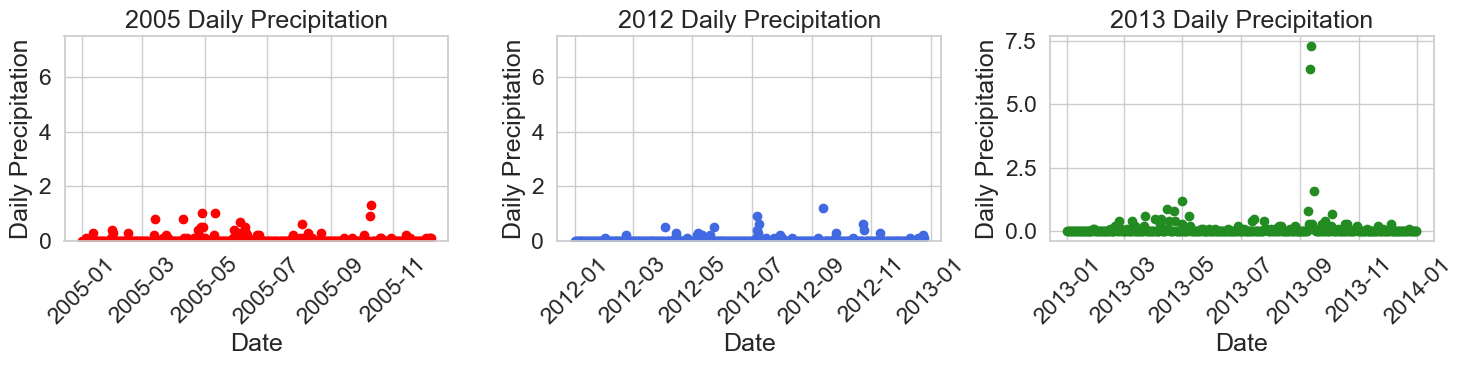

In [136]:
# Create 1 row and 3 columns subplot
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

#2005 plot
ax[0].scatter(precip_2005_daily.index, precip_2005_daily["HPCP"],color="red")
ax[0].set_title("2005 Daily Precipitation")
ax[0].set(ylim=[0, 7.5])
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Daily Precipitation")
ax[0].tick_params(axis='x', rotation=45)

# 2012 plot
ax[1].scatter(precip_2012_daily.index, precip_2012_daily["HPCP"],color="royalblue")
ax[1].set_title("2012 Daily Precipitation")
ax[1].set(ylim=[0, 7.5])
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Daily Precipitation")
ax[1].tick_params(axis='x', rotation=45)

#2013
ax[2].scatter(precip_2013_daily.index,precip_2013_daily["HPCP"],color="forestgreen")
ax[2].set_title("2013 Daily Precipitation")
ax[2].set_xlabel("Date")
ax[2].set_ylabel("Daily Precipitation")
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# From the graphs we can tell that on September 12, 2013, there was a major flood where the daily precipitation reached up to 7.5 inches in one day. This is lead to catastrophic flooding. The normal max daily precipitation is 0.6 inches and suddenly on September 12, 2013, there was an hour were 2.2 inches. 

In [137]:
# Highest hourly precipitation values
print(precip_2012.max())

precip_2013_max= precip_2013.max()
print(precip_2013_max)

max_precip_timestamps = precip_2013.loc[precip_2013["HPCP"] == 2.2].index
print(max_precip_timestamps)

STATION                 COOP:050843
STATION_NAME        BOULDER 2 CO US
ELEVATION                    1650.5
LATITUDE                    40.0338
LONGITUDE                 -105.2811
HPCP                            0.6
Measurement Flag                  }
Quality Flag                       
dtype: object
STATION                 COOP:050843
STATION_NAME        BOULDER 2 CO US
ELEVATION                    1650.5
LATITUDE                    40.0338
LONGITUDE                 -105.2811
HPCP                            2.2
Measurement Flag                  g
Quality Flag                       
dtype: object
DatetimeIndex(['2013-09-12'], dtype='datetime64[us]', name='DATE', freq=None)


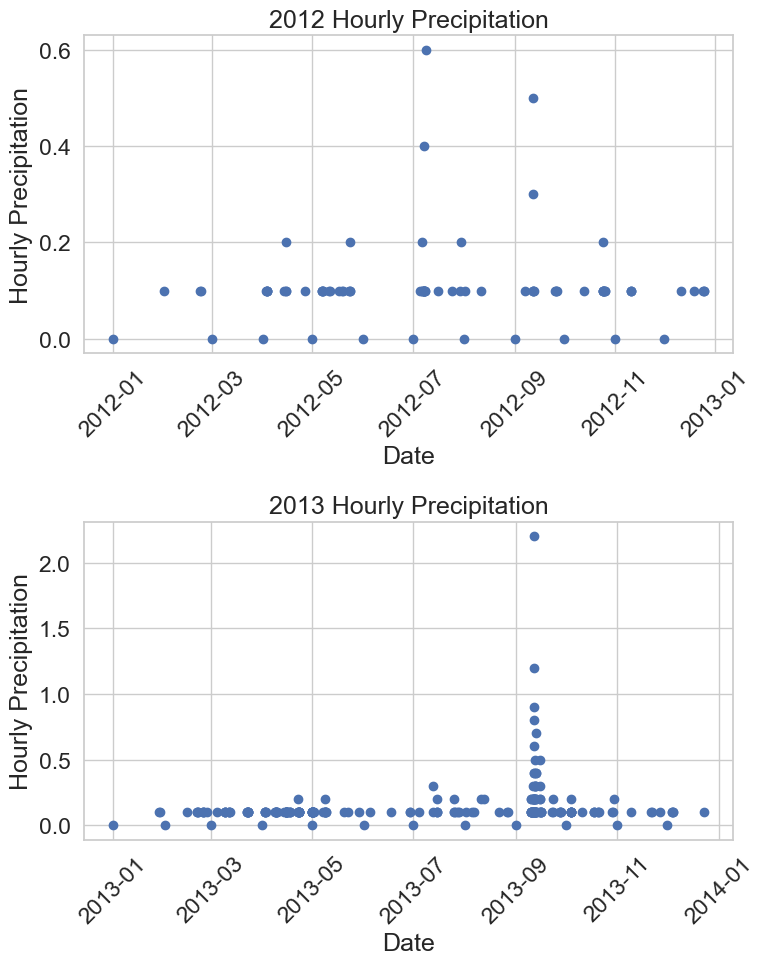

In [138]:
# Create 2 row and 1 columns
f, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))

# 2012 plot Hourly
ax[0].scatter(precip_2012.index, precip_2012["HPCP"])
ax[0].set_title("2012 Hourly Precipitation")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Hourly Precipitation")
ax[0].tick_params(axis='x', rotation=45)

#2013
ax[1].scatter(precip_2013.index,precip_2013["HPCP"])
ax[1].set_title("2013 Hourly Precipitation")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Hourly Precipitation")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

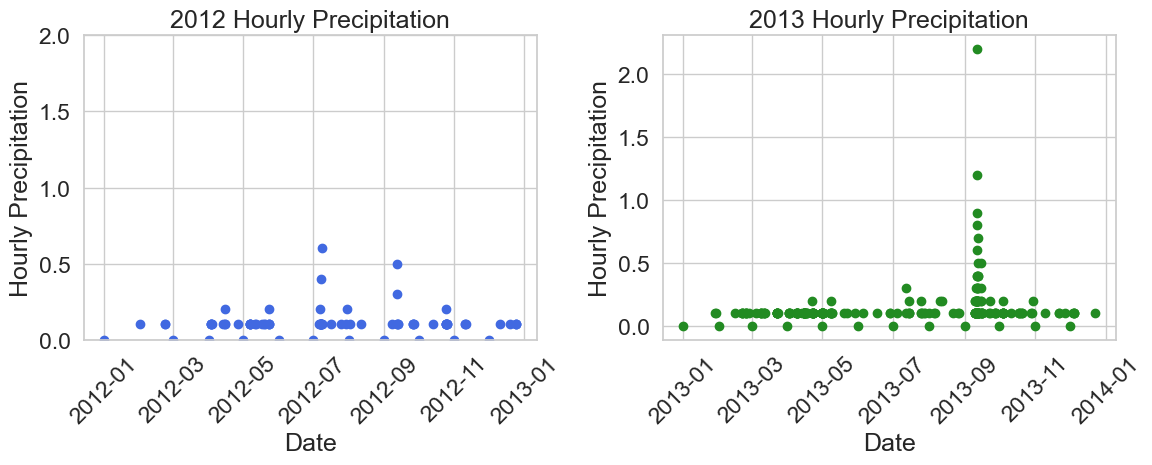

In [139]:
# Plot 2012 to scale with 2013
# Create 2 row and 1 columns
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# 2012 plot Hourly
ax[0].scatter(precip_2012.index, precip_2012["HPCP"],color="royalblue")
ax[0].set_title("2012 Hourly Precipitation")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Hourly Precipitation")
ax[0].set(ylim=[0, 2])
ax[0].tick_params(axis='x', rotation=45)

#2013
ax[1].scatter(precip_2013.index,precip_2013["HPCP"],color="forestgreen")
ax[1].set_title("2013 Hourly Precipitation")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Hourly Precipitation")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




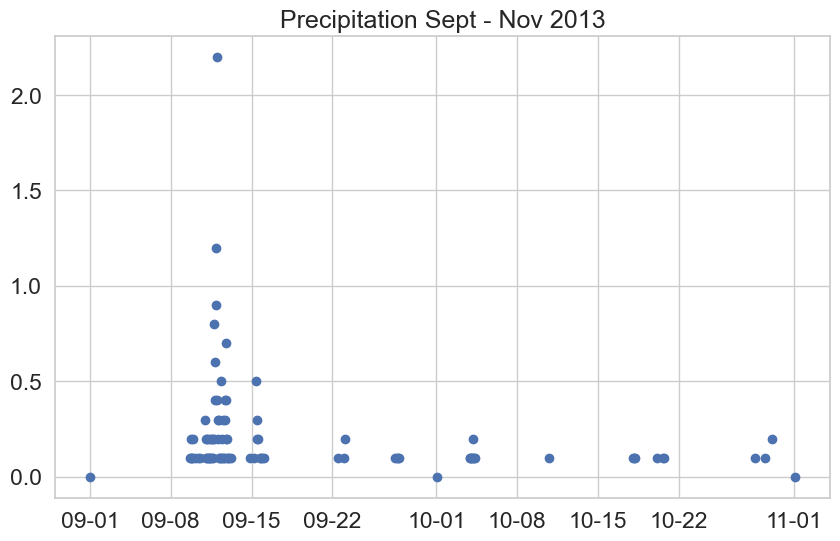

<Figure size 640x480 with 0 Axes>

In [150]:
# Daily precipitation from September 1, 2013 to November 1 2013

f, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x=flood_data.index.values,
           y=flood_data["HPCP"])

# Define the date format
date_form = DateFormatter("%m-%d")
ax.xaxis.set_major_formatter(date_form)
ax.set(title="Precipitation Sept - Nov 2013")
plt.show()
september_2013=precip_2013_daily["2013-09-01":"2013-11-1"]
ax.scatter(september_2013.index,september_2013["HPCP"],color="forestgreen")
ax.set_title("Daily Precipitation (Sept 1 - Nov 1, 2013)")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Precipitation")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Precipitation on September 11, 2013 to the September 13,2013

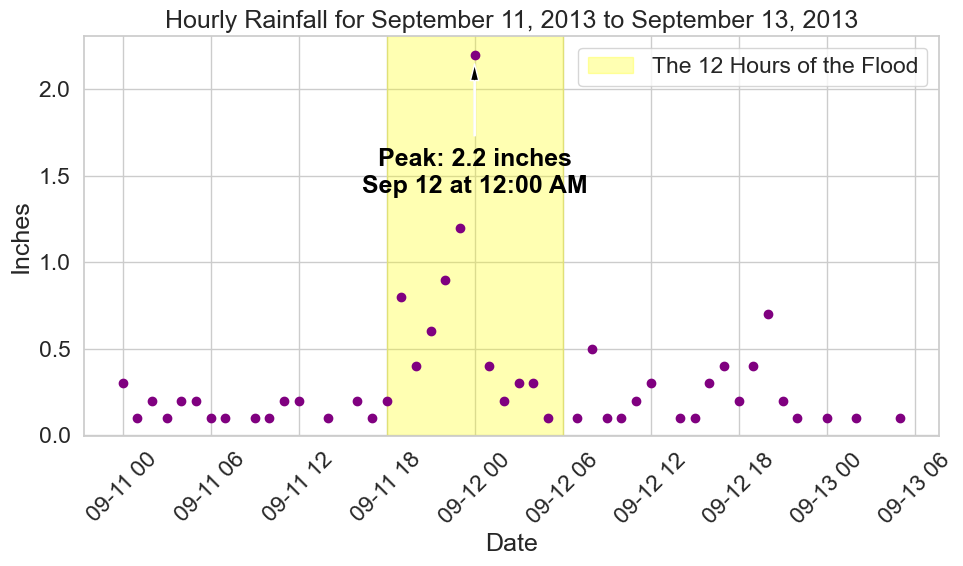

In [154]:
# A closer look at the hourly precipitation around September 12, 2013
sept_11_13_2013 = precip_2013.loc["2013-09-11":"2013-09-13"]

f, ax = plt.subplots(figsize=(10, 6))


ax.scatter(x=sept_11_13_2013.index.values,
           y=sept_11_13_2013["HPCP"],
           color="purple",
           zorder=3)

ax.set(title="Hourly Rainfall for September 11, 2013 to September 13, 2013",
       ylabel="Inches",
       xlabel="Date")
ax.tick_params(axis='x', rotation=45)

# Highlight the 12 hours of the heaviest flood window
start_highlight = pd.Timestamp("2013-09-11 18:00:00")
end_highlight = pd.Timestamp("2013-09-12 06:00:00")
ax.axvspan(xmin=start_highlight, 
           xmax=end_highlight, 
           color="yellow", 
           alpha=0.3,          
           label="The 12 Hours of the Flood",
           zorder=1) 

# Calculate peak values from the plotted window
peak_time = sept_11_13_2013["HPCP"].idxmax()  
peak_value = sept_11_13_2013["HPCP"].max()
clean_time_string = peak_time.strftime("%b %d at %I:%M %p")

# Annotate the peak rainfall point
ax.annotate(
    text=f"Peak: {peak_value} inches\n{clean_time_string}",
    xy=(peak_time, peak_value),              
    xytext=(peak_time, peak_value - 0.8),    # OPTIONAL FIX: Shifted text slightly ABOVE the point to avoid crowding data
    arrowprops=dict(
        facecolor='black',             
        shrink=0.1,                    
        width=1,                       
        headwidth=6                    
    ),
    horizontalalignment='center',
    color='black',
    weight='bold'
)

plt.tight_layout()
plt.legend(loc="upper right")
plt.show()
